# 1 Foundation Models

### Definition:
Large DL model that has been pre-trained on a massive and diverse dataset of time series from various domains with the goal of learning general-purpose patterns, relationsships, and underlying structures common across different types of time series.

### Core Idea:
Knowledge acquired during pre-training can be "transferred" and adapted to new, unseen time series tasks with minimal or no additional training. This capability is often referred to as:
- **Zero-Shot forecasting:** Generate forecasts without training on the time series
- **Few-Shot forecasting:** The model can achieve high performance on a new task with only a small amount of task-specific data for fine-tuning

### Main Architectures:
**Transformers**
- **Core Idea:** Rely on self-attention mechanisms to capture long-range dependencies within the time series data
- **Patching:** Time series are often divided into fixed-size "patches" which are then treated as "tokens" for the Transformer, similar to words in NLP. Some models use multi-resolution patching to capture patterns at different scales
- **Positional Encoding:** Since self-attention doesn't inherently understand sequence order, positional encodings are added to the patches to embed temporal information
- **Encoder-Decoder or Decoder-Only:** Similar to NLP Transformers, they can use an encoder-decoder structure (encoder learns historical context, decoder generates forecasts) or a decoder-only architecture (like GPT, where the model autoregressively predicts future values)

**MLP-based Architectures**

In contrast to the large transformer models recent research shifts more and more to lightweight stacked MLPs

**Core Idea:** They leverage simple linear layers to capture temporal patterns and mix information across different time series variables. Most of the also use patching

Okay, I will combine the two tables, using the first table as the base and adding the new models and updated information from the second table. I'll maintain the existing columns and add new ones if a relevant feature is only present in the second table and applicable to a new model.

Here's the combined table:

| Feature | MOMENT | Moirai | Lag-LLaMa | Chronos | TimesFM | TimeGPT-1 | TinyTimeMixers | TOTEM | TimeXer | TimeRXL (Timer-XL) | ExoTST | TabPFN-TS |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| **Citation** | [Goswami et al., Feb 2024](https://arxiv.org/abs/2402.03885) | [Woo et al., Feb 2024](https://arxiv.org/abs/2402.02592) | [Rasul et al., Oct 2023](https://arxiv.org/abs/2310.08278) | [Ansari et al., Mar 2024](https://arxiv.org/abs/2403.07815) | [Das et al., Oct 2023](https://arxiv.org/abs/2310.10688) | [Garza & Mergenthaler-Canseco, Oct 2023](https://arxiv.org/abs/2310.03589) | [Ekambaram et al., Jan 2024](https://arxiv.org/abs/2401.03955) | [Talukder et al., Feb 2024](https://arxiv.org/abs/2402.16412) | [Wang et al., 2024](https://arxiv.org/abs/2402.16412) | [Liu et al., 2024](https://arxiv.org/abs/2402.16412) | [Tayal et al., 2024](https://arxiv.org/abs/2402.16412) | [Hoo et al., 2025](https://arxiv.org/abs/2402.16412) |
| **Base Architecture** | T5 encoder | Encoder-only transformer (masked-encoder Universal FT) | LLaMa | T5 (encoder-decoder) | Decoder-only Transformer (GPT-like) | Transformer (encoder-decoder) | MLP-Mixer (TSMixer + gated attention) | VQ-VAE | Transformer + exogenous-aware modules | Decoder-only Transformer (TimeAttention) | Transformer w/ cross-temporal fusion | TabPFN (Transformer for tabular regression) |
| **Sizes (params)** | 40M, 125M, 385M | 14M, 91M, 311M (Small: 14M; Base: 61M; Large: 111M) | 200M | 20M, 46M, 200M, 710M (Mini: 20M; Small: 46M; Base: 200M; Large: 710M) | 17M, 70M, 200M | ? | <1M (~~1M per variant) | 0.3M | Not specified | Not specified | Not specified | 11M |
| **Open Source** | ✓ | ✓ | ✓ | ✓ | ✓ (GitHub) | ✓ (GitHub) | ✓ | ✓ | ✓ | ✓ | Unknown | ✓ |
| **Evaluation Tasks** | Forecasting, Classification, Anomaly detection, Imputation | Forecasting (universal, multi-domain) | Forecasting | Forecasting (probabilistic) | Forecasting (zero-shot) | Forecasting; Anomaly Detection | Forecasting (multivariate zero/few-shot) | Forecasting, Classification, Anomaly detection, Imputation | Forecasting w/ exogenous inputs | Unified time-series forecasting | Forecasting w/ exogenous covariates | Forecasting (tabular regression) |
| **Total Observations (Training Data)** | 1.13B++ | 27.65B (27B observations; LOTSA archive) | 0.36B | 84B (Public datasets + GP synthetic) | 100B (time-points; real+synth) | 100B (cross-domain series) | 244M (250M (R1) / 700M (R2) public samples) | N/A | Real-world time series, 12 benchmarks | Large-scale pretraining | Carbon flux, public benchmarks | Synthetic-only pretraining |
| **Time Series (#Series Training)** | 13M | 4M (Multi-dataset (9 domains)) | 11K | 11M (~28 datasets, 1M augmentations) | ? (tens of millions) | ? (many domains) | N/A (few million) | N/A | varied by dataset | many series | dataset-specific | varied per dataset |
| **Public Data?** | ✓ | ✓ (LOTSA public) | ✓ | ✓ | ✓ (public: Wiki, M4, etc.) | × (30 days free trail) | ✓ | ✓ | Yes | Yes | Yes | Synthetic only |
| **Tokenization** | Fixed-length patches | Multi-scale patches (Patch tokens (non-overlapping)) | Lag features | Scaling & quantization (Quantized value tokens (fixed vocab)) | Fixed-length patches (Non-overlapping patches (len 32→128)) | ? (Raw values + positional encodings) | Adaptive Patching (Adaptive patch embedding; prefix tokens) | VQVAE-based | Patch-wise self-attention; variate-wise cross-attention | Flattened time-series patches (TimeAttention) | Uses past endogenous & current exogenous as distinct tokens | Hand-engineered TS features → tabular input |
| **Objective** | Reconstruction error (MSE) | Forecast log likelihood of mixture distribution | Forecast log likelihood of Student’s t distribution | Forecast Cross-entropy loss | Forecasting error (MSE) | ? (Minimize forecasting error, e.g. MASE/MSE) | Forecasting error (MSE) | Reconstruction + Commitment error | (Likely) MSE | (Likely) MSE | (Likely) MSE | Probabilistic regression (quantiles) |
| **Distributional Prediction** | In progress (post hoc) | ✓ | ✓ | ✓ | × | ✓ (post hoc) | × | ✓ | No | No | No | ✓ |
| **Interpretability** | ✓ | × | × | ✓ | ✓ | × | × | × | No | No | No | No |
| **Any-variate Prediction** | ✓ (Channel independence) | ✓ (Flattening; Any-variate attention) | × | × | × (univariate only) | ✓ (?) (multiseries) | ✓ (Channel Independence + Mixing; multi-channel support) | ✓ (Flattening) | ✓ (endogenous + exogenous) | ✓ (multivariate patches) | ✓ (treats exogenous separately) | Single-variate |
| **Context length** | 512 | adjustable (up to 512) | 1024 | 512 | 512 (≤512 (freq-dependent)) | ? | 512 (52–1536 (models vary)) | 512 | Depends on data | Long (unbounded) | Task-specific | Fixed feature set |
| **Scaling (Model)** | ✓ | ✓ | ✓ | ✓ | ✓ | × | ✓ | ✓ | | | | |
| **Scaling (Data)** | × | × | ✓ | × | ✓ | × | ✓ | ✓ | | | | |
| **Notes** | | Multi-frequency patches; large data | | Large vocab; fixed 512 context | Mix of real/synthetic data; context varies | Massive data pretraining | 14× fewer params vs LLM-TS; tiny model | | Incorporates exogenous variables | Causal, long-context prediction | Robust to missing/noisy exogenous | Only synthetic pretraining; 11M model |

## 1.2 Tiny Time Mixers


### Architecture

Multi-level architecture based on four primary components:
- **Backbone:** Built using components of TSMixer architecture which combines MLP-mixer blocks with simple gated attention. This helps mixing features within patches, across patches and across channels. Gated attention helps the model focus on important featuresespecially for long-term interactions without the need of complex multi-head-self-attention.
- **Decoder:** Same as the backbone but only 10-20% of the size.
- **Forecast Head:** Linear head to produce the final forecast.
- **Exogenous Mixer:** Dedicated MLP-Mixer with focus on cross channel attention.

The decoder, forecast head and optionally the exogenous mixer are updated during finetuning.

Improvements to TSMixer:
- **Adaptive Patching:** Allows varying patch lengths across different layers of the network. Different datasets benefit from different patch length.
- **Diverse Resolution Sampling:** Adresses different granularities of time series. Pretrained models only for hourly to weekly granularity.
- **Resolution Prefix Tuning:** Embeds resolution information into the first patch.

### Covariate Support
Initially TTM models are pre-trained channel independent. Channel mixing can be activated during finetuning. Exogenous mixer layer brings covariate information into the decocoder channel-mixing part.


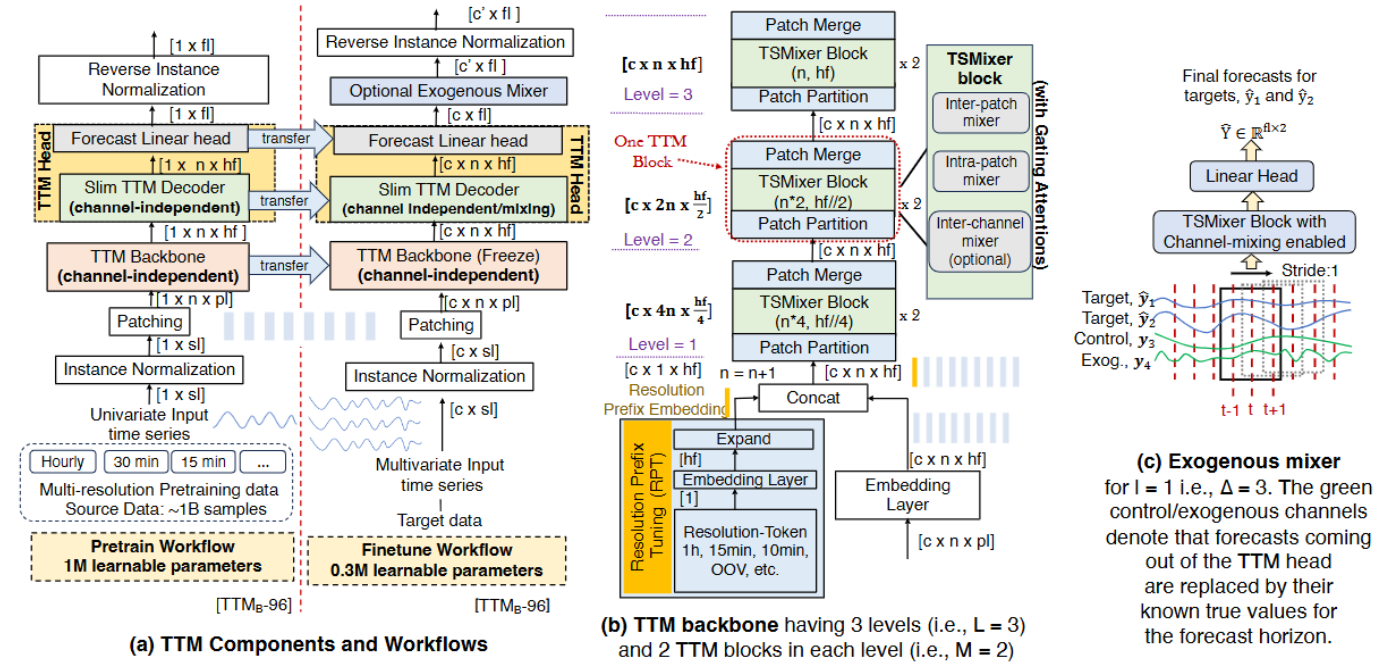

## 1.3 MOIRAI

### Architecture

- **Base:** Patch based masked encoder
- **Cross-Frequency Learning:** Pre-trained multiple input- and output-layer for different patch sizes to support variing granularities
- **Any-Variate Attention:** Treats both the time and variate axes simultaneaously as a single sequence via flattening. Uses Rotary Position Emeddings (RoPE) for time axis and learned binary attention biases for variate axis.This allows an arbritary number of variates as input.
- **Mixture Distribution:** Model selects a suitable combination of distribution functions to describe the data (normal, student-t, log-normal and negative binominal)

### Covariate Support
via **any-variate attention**

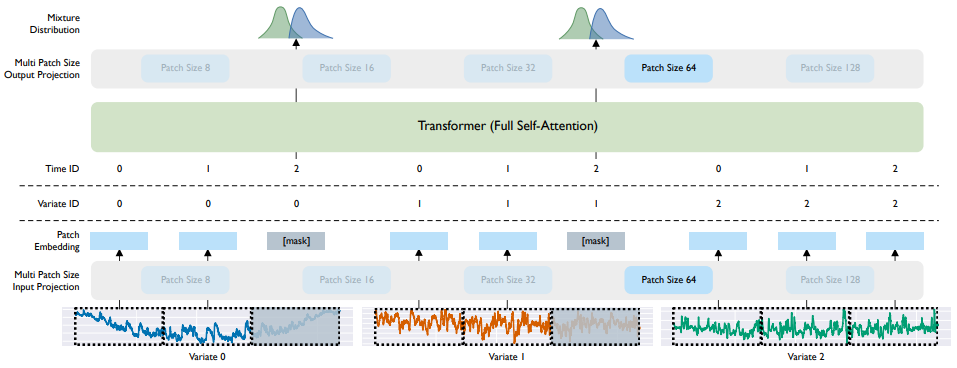


## 1.4 TimeGPT

### Architecture

- Based on Encoder-Decoder Transformer with self-attention.
- No patching. Takes historic window adds positional encoding as input for the encoder.
- Uses residual connections and layer normalization to stabilize training
- Decoder generates actual forecasts from encoder output over its multi head attention

### Covariate Support
No details about this in the paper but supported. Targets and Covariates are embedded together as input for attention.

## 1.5 TimesFM

### Architecture

- Uses input patching
- **Masked Multi head attention:** allows the model to weigh the importance of historic patches for the next prediction while adhering causal constraint
- Feed-forward neural networks to learn complex linear relationships
- Uses residual connections and layer normalization to stabilize training

### Covariate Support
Use of external regressor:
- fits a seperate linear regressor model to capture covariate effects
- forecasts residuals with timesfm
- combines both forecasts
- Two options: regressor first and timesfm on residuals or timesfm first and regressor on those residuals

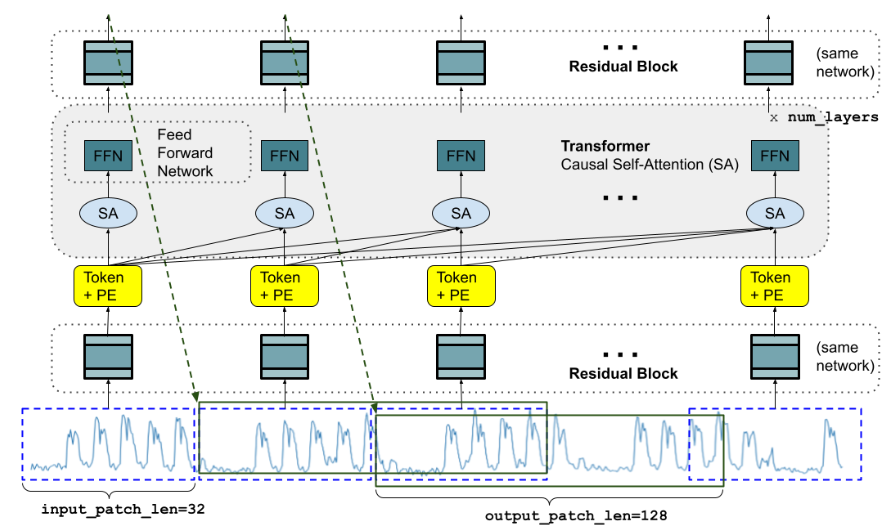

## 1.6 Chronos

### Architecture

- Based on the T5-architecture
- Tokenization: Scales by the absolute mean first. Those scaled values are then quantized into a fixed number of uniformly spaced bins which corresponds to a unique token in a predefined vocabulary.
- Decoder only for orginal Chronos models and Encoder-Decoder for bolt models.
- Pretrained using cross entropy loss

### Covariate Support
Same as TimesFM. No native support but use of expernal regressors. Train regressor to get residuals and predict residuals with chronos.

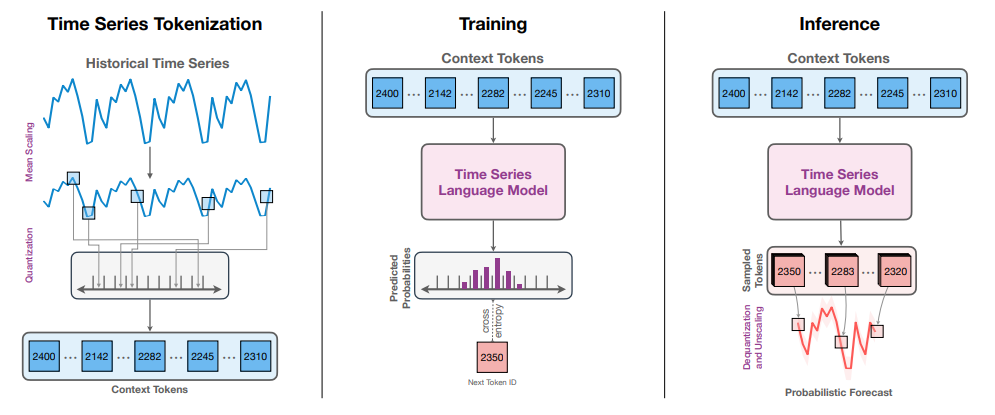